In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

In [2]:
class EnvironmentalSensorSimulator:
    def __init__(self):
        self.models = {}
        self.scalers_X = {}
        self.scalers_y = {}
        self.sensor_ids = None
        # Update parameter names to match your data
        self.parameters = ['soil_moisture', 'soil_temperature', 
                         'soil_electrocoductivity', 'battery_level']
        
    def prepare_features(self, df, parameter, sensor_id):
        """
        Create time-based features from datetime
        """
        features = pd.DataFrame()
        
        # Time-based features
        features['hour'] = df['datetime'].dt.hour
        features['day'] = df['datetime'].dt.day
        features['month'] = df['datetime'].dt.month
        features['day_of_week'] = df['datetime'].dt.dayofweek
        
        # Add lagged values
        for i in range(1, 4):
            features[f'lag_{i}'] = df[parameter].shift(i)
            
        # Add rolling statistics
        features['rolling_mean_3'] = df[parameter].rolling(window=3).mean()
        features['rolling_std_3'] = df[parameter].rolling(window=3).std()
        
        return features.dropna()
    
    def fit(self, data):
        """
        Train models for each sensor and parameter
        """
        # Clean and prepare the DataFrame
        df = data.copy()
        
        # Drop unnecessary columns and convert datetime
        df = df.drop(['id', 'owner'], axis=1)
        df['datetime'] = pd.to_datetime(df['createdAt'])
        
        # Get unique sensor IDs
        self.sensor_ids = df['sensor_id'].unique()
        
        # Train separate models for each sensor and parameter
        for sensor_id in self.sensor_ids:
            sensor_data = df[df['sensor_id'] == sensor_id]
            
            for parameter in self.parameters:
                model_key = f"{sensor_id}_{parameter}"
                self.models[model_key] = LinearRegression()
                self.scalers_X[model_key] = StandardScaler()
                self.scalers_y[model_key] = StandardScaler()
                
                # Prepare features and target
                X = self.prepare_features(sensor_data, parameter, sensor_id)
                y = sensor_data[parameter].iloc[3:]  # Remove first 3 rows to match feature set
                
                if len(X) < 4:  # Skip if not enough data
                    continue
                    
                # Split data
                X_train, X_test, y_train, y_test = train_test_split(
                    X, y, test_size=0.2, random_state=42
                )
                
                # Scale features and target
                X_train_scaled = self.scalers_X[model_key].fit_transform(X_train)
                y_train_scaled = self.scalers_y[model_key].fit_transform(y_train.values.reshape(-1, 1))
                
                # Train model
                self.models[model_key].fit(X_train_scaled, y_train_scaled)
                
                # Calculate metrics
                X_test_scaled = self.scalers_X[model_key].transform(X_test)
                y_test_scaled = self.scalers_y[model_key].transform(y_test.values.reshape(-1, 1))
                score = self.models[model_key].score(X_test_scaled, y_test_scaled)
                print(f"R² Score for {sensor_id} - {parameter}: {score:.4f}")
        
        return self
    
    def generate_values(self, start_datetime, n_points, interval_minutes=60):
        """
        Generate simulated values for all sensors and parameters
        """
        results = []
        
        # Store initial values from historical data
        initial_values = {
            'soil_moisture': 13,  # From your sample data
            'soil_temperature': 25.0,
            'soil_electrocoductivity': 63,
            'battery_level': 86
        }
        
        for sensor_id in self.sensor_ids:
            # Initialize history for this sensor with realistic values
            history = {param: initial_values[param] for param in self.parameters}
            
            dates = pd.date_range(
                start=start_datetime,
                periods=n_points,
                freq=f'{interval_minutes}min'
            )
            
            for date in dates:
                row = {
                    'createdAt': date,
                    'sensor_id': sensor_id
                }
                
                # Generate values for each parameter
                for parameter in self.parameters:
                    model_key = f"{sensor_id}_{parameter}"
                    if model_key not in self.models:
                        continue
                        
                    # Prepare features
                    features = pd.DataFrame({
                        'hour': [date.hour],
                        'day': [date.day],
                        'month': [date.month],
                        'day_of_week': [date.dayofweek],
                        'lag_1': [history[parameter]],
                        'lag_2': [history[parameter]],
                        'lag_3': [history[parameter]],
                        'rolling_mean_3': [history[parameter]],
                        'rolling_std_3': [0.5]  # Add some variation
                    })
                    
                    # Scale and predict
                    scaled_features = self.scalers_X[model_key].transform(features)
                    scaled_prediction = self.models[model_key].predict(scaled_features)
                    prediction = self.scalers_y[model_key].inverse_transform(scaled_prediction.reshape(-1, 1))[0][0]
                    
                    # Add small random variations to make predictions more realistic
                    if parameter == 'soil_moisture':
                        noise = np.random.normal(0, 0.8)
                    elif parameter == 'soil_temperature':
                        noise = np.random.normal(0, 0.3)
                    elif parameter == 'soil_electrocoductivity':
                        noise = np.random.normal(0, 1.0)
                    else:  # battery_level
                        noise = np.random.normal(0, 0.4)
                    
                    prediction = max(0, prediction + noise)  # Ensure no negative values
                    
                    # Update history and store prediction
                    history[parameter] = prediction
                    row[parameter] = round(prediction, 1)
                
                results.append(row)
        
        return pd.DataFrame(results)

In [41]:
# Initialize and train
simulator = EnvironmentalSensorSimulator()
simulator.fit(df)

# Generate new data
start_time = datetime.now()
simulated_data = simulator.generate_values(
    start_datetime=start_time,
    n_points=24,
    interval_minutes=60
)

# Display results
print("\nSimulated Data Sample:")
print(simulated_data.head())


R² Score for A102 - soil_moisture: 1.0000
R² Score for A102 - soil_temperature: 1.0000
R² Score for A102 - soil_electrocoductivity: 1.0000
R² Score for A102 - battery_level: 1.0000
R² Score for A101 - soil_moisture: 1.0000
R² Score for A101 - soil_temperature: 1.0000
R² Score for A101 - soil_electrocoductivity: 1.0000
R² Score for A101 - battery_level: 1.0000

Simulated Data Sample:
                   createdAt sensor_id  soil_moisture  soil_temperature  \
0 2025-02-21 12:02:40.108365      A102           13.2              25.1   
1 2025-02-21 13:02:40.108365      A102           14.3              24.8   
2 2025-02-21 14:02:40.108365      A102           13.7              24.3   
3 2025-02-21 15:02:40.108365      A102           13.7              24.1   
4 2025-02-21 16:02:40.108365      A102           14.1              23.9   

   soil_electrocoductivity  battery_level  
0                     64.4           86.6  
1                     65.3           86.6  
2                     66.0     

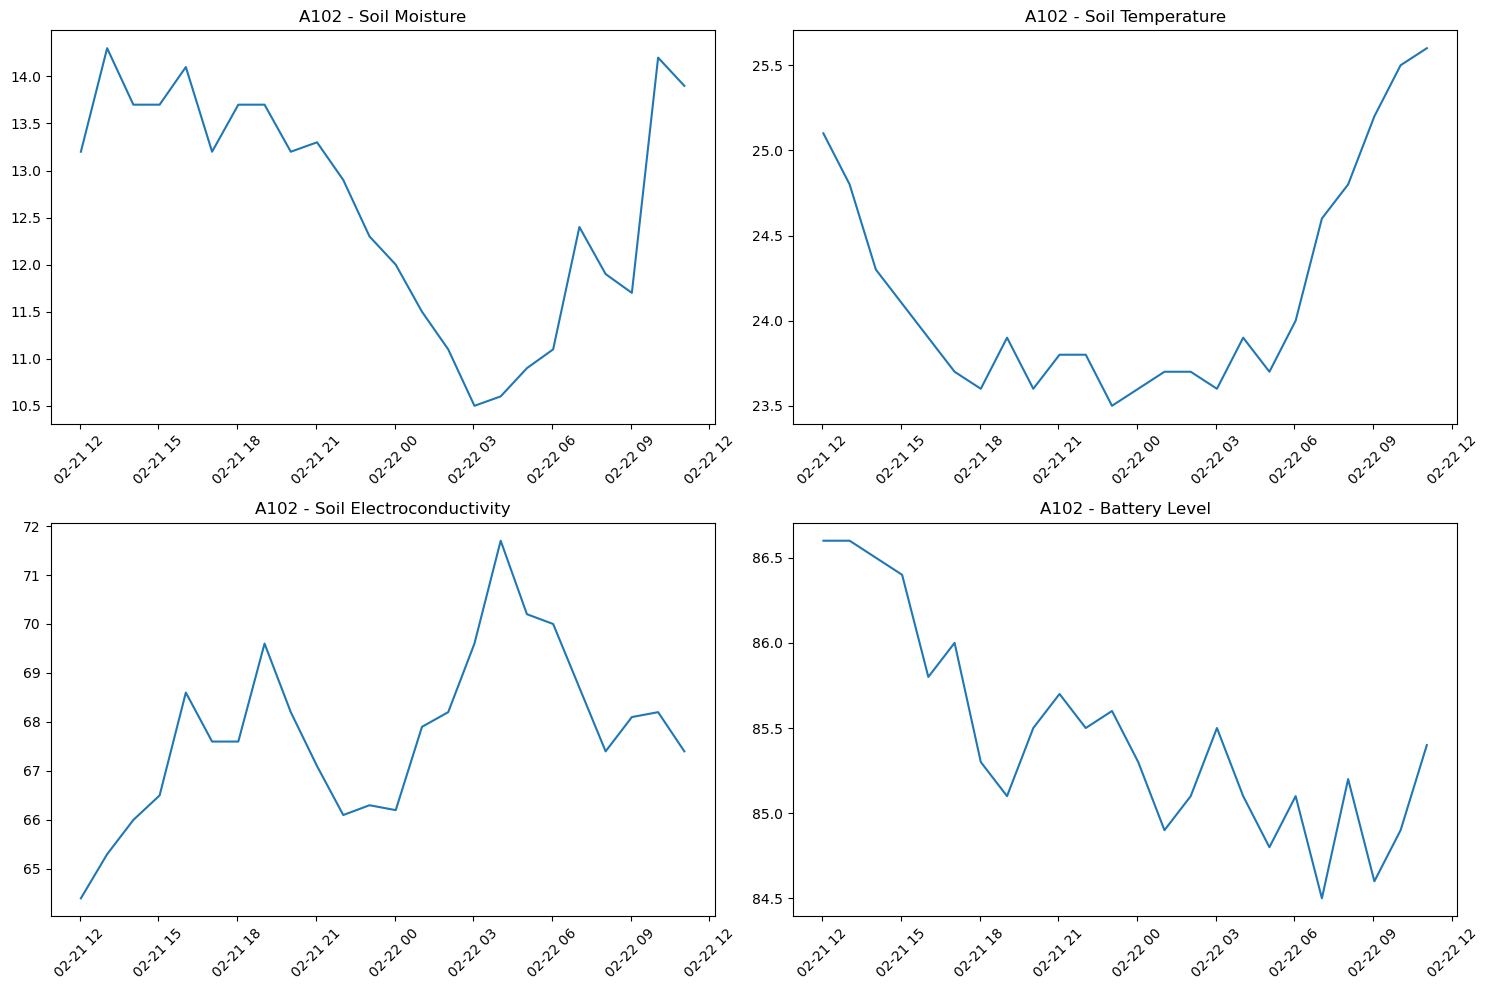

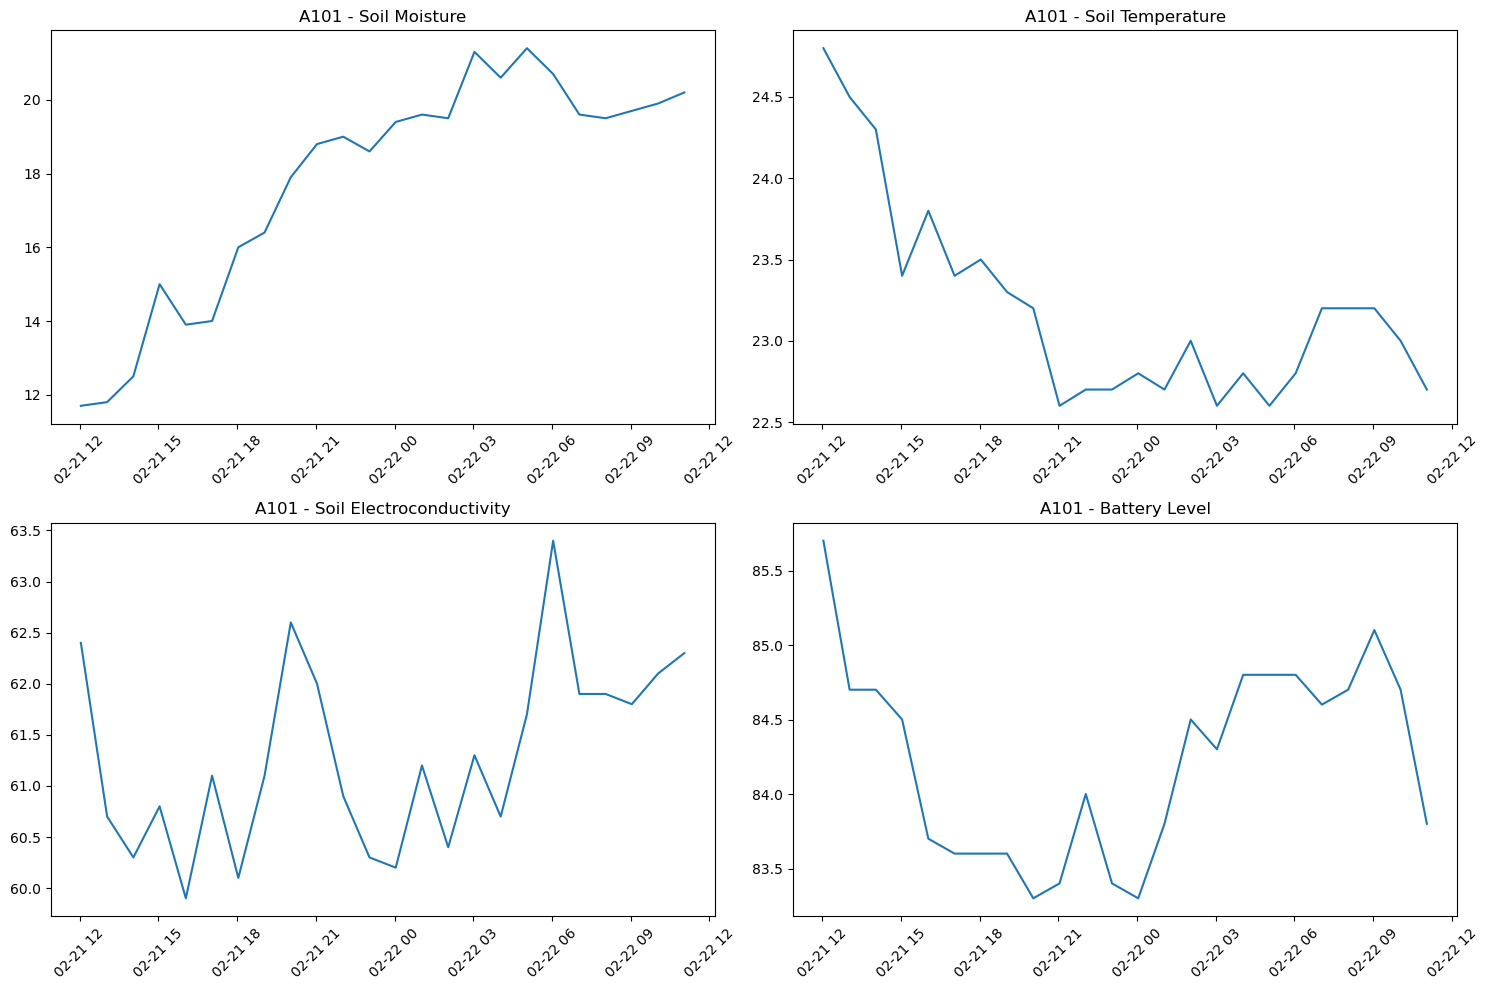

In [42]:
for sensor_id in simulated_data['sensor_id'].unique():
    sensor_data = simulated_data[simulated_data['sensor_id'] == sensor_id]
    
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 2, 1)
    plt.plot(sensor_data['createdAt'], sensor_data['soil_moisture'])
    plt.title(f'{sensor_id} - Soil Moisture')
    plt.xticks(rotation=45)
    
    plt.subplot(2, 2, 2)
    plt.plot(sensor_data['createdAt'], sensor_data['soil_temperature'])
    plt.title(f'{sensor_id} - Soil Temperature')
    plt.xticks(rotation=45)
    
    plt.subplot(2, 2, 3)
    plt.plot(sensor_data['createdAt'], sensor_data['soil_electrocoductivity'])
    plt.title(f'{sensor_id} - Soil Electroconductivity')
    plt.xticks(rotation=45)
    
    plt.subplot(2, 2, 4)
    plt.plot(sensor_data['createdAt'], sensor_data['battery_level'])
    plt.title(f'{sensor_id} - Battery Level')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

In [43]:
ls

 Volume in drive C is Windows 
 Volume Serial Number is C412-34B0

 Directory of C:\Users\robot\Vault\Spring24\CAPSTONE\Lab2\function-calling-for-sensors-at-the-edge\Data

21/02/2025  12:02    <DIR>          .
21/02/2025  10:51    <DIR>          ..
21/02/2025  10:52    <DIR>          .ipynb_checkpoints
06/02/2025  08:45           402,750 August-October-2021-sectionA1-data.csv
06/02/2025  08:45           980,663 August-October-2021-sectionA2-data.csv
06/02/2025  08:45           853,090 August-October-2021-sectionA3-data.csv
06/02/2025  08:45         1,671,416 August-October-2021-sectionA4-data.csv
06/02/2025  08:45         1,607,282 August-October-2021-sectionC10-data.csv
06/02/2025  08:45         3,932,290 August-October-2021-sectionC9-data.csv
21/02/2025  12:02           342,268 regression.ipynb
               7 File(s)      9,789,759 bytes
               3 Dir(s)  18,386,149,376 bytes free


In [51]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the CSV file
df = pd.read_csv("August-October-2021-sectionA1-data.csv")

# Remove irrelevant columns
df.drop(columns=["id", "owner"], inplace=True)

# Convert 'createdAt' to datetime format
df['createdAt'] = pd.to_datetime(df['createdAt'])
# df['datetime'] = pd.to_datetime(df['createdAt'])

# Extract time-based features
df['hour'] = df['createdAt'].dt.hour
df['day'] = df['createdAt'].dt.day
df['month'] = df['createdAt'].dt.month
df['weekday'] = df['createdAt'].dt.weekday

# Features and target variables
X = df[['soil_moisture', 'soil_temperature', 'soil_electrocoductivity', 'battery_level', 'hour', 'day', 'month', 'weekday', 'sensor_id']]
y = df[['soil_moisture', 'soil_temperature', 'soil_electrocoductivity', 'battery_level']]

# One-hot encode 'sensor_id'
preprocessor = ColumnTransformer(
    transformers=[('sensor_id', OneHotEncoder(handle_unknown='ignore'), ['sensor_id'])],
    remainder='passthrough'
)

# Build the pipeline
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', MultiOutputRegressor(LinearRegression()))
])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions and evaluate
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")


# Generate new simulated data (example)
new_data = pd.DataFrame({
    'soil_moisture': [20],
    'soil_temperature': [22.5],
    'soil_electrocoductivity': [120],
    'battery_level': [90],
    'hour': [10],
    'day': [15],
    'month': [8],
    'weekday': [2],
    'sensor_id': ['A201']
})
simulated_output = model.predict(new_data)

print("\nSimulated Data Output:")
print(simulated_output)

Mean Absolute Error: 0.00
MSE: 0.00
R2 Score: 1.00

Simulated Data Output:
[[ 20.   22.5 120.   90. ]]


Model Evaluation:
MAE: 10.21
MSE: 529.51
R2 Score: 0.54


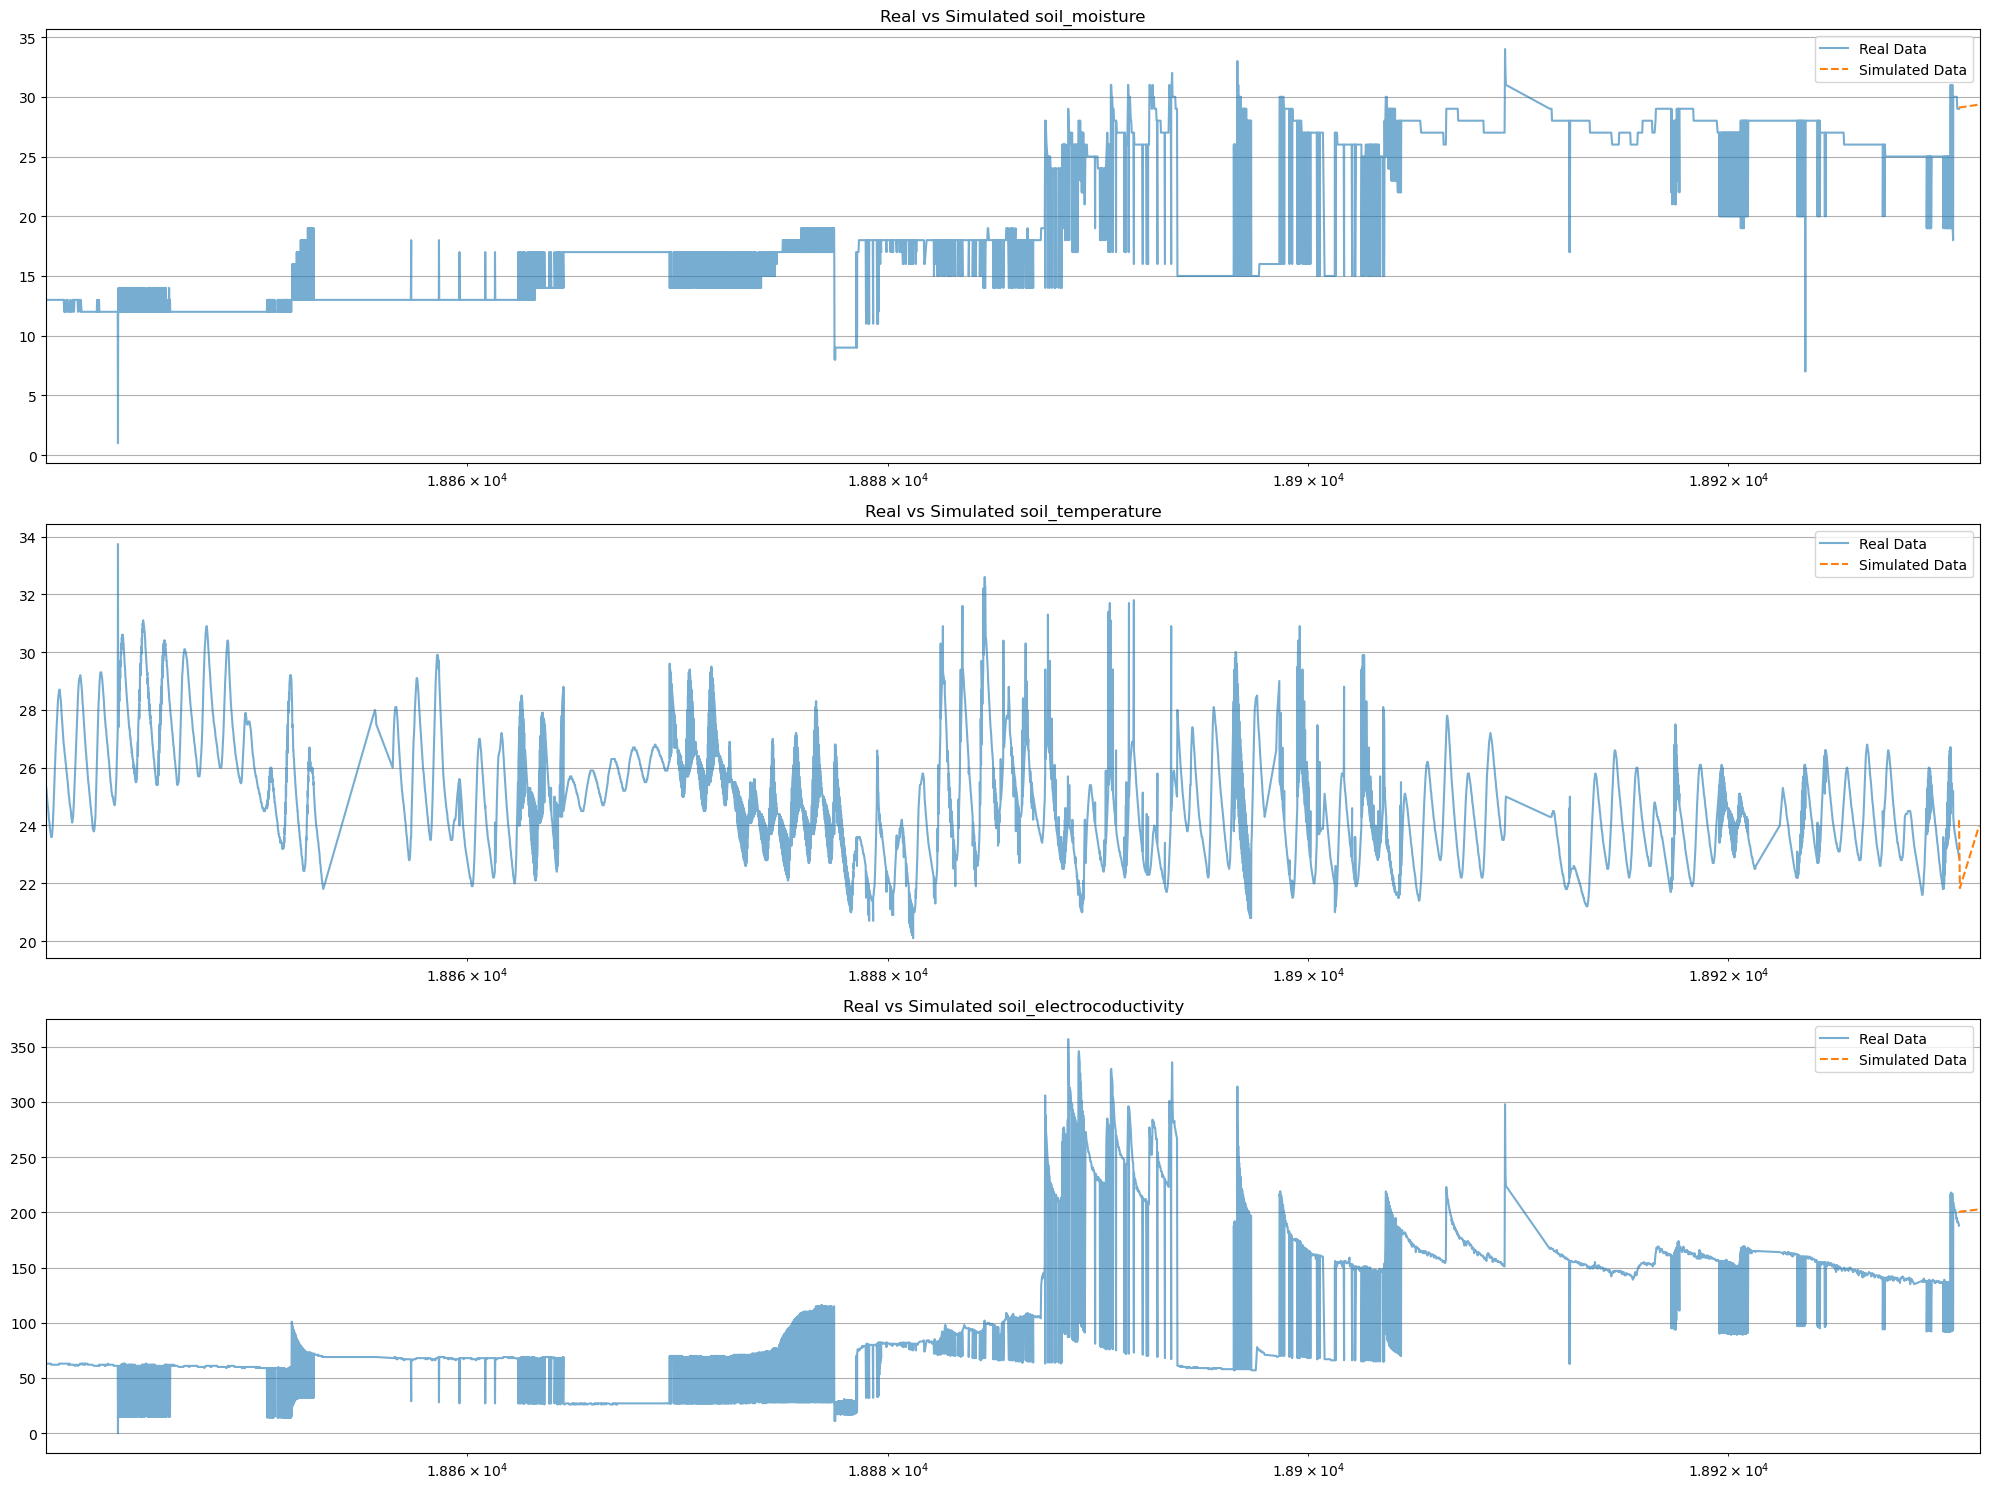

In [64]:
# find y(s) for sensorID

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from datetime import datetime, timedelta

#load dataset
df = pd.read_csv("August-October-2021-sectionA1-data.csv")

#preprocess data
df['createdAt'] = pd.to_datetime(df['createdAt'])
df['hour'] = df['createdAt'].dt.hour
df['day'] = df['createdAt'].dt.day
df['month'] = df['createdAt'].dt.month
df['weekday'] = df['createdAt'].dt.weekday

#features and target
X = df[['hour', 'day', 'month', 'weekday', 'battery_level']]
y = df[['soil_moisture', 'soil_temperature', 'soil_electrocoductivity']]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#train regression model
model = LinearRegression()
model.fit(X_train, y_train)

#predictions
y_pred = model.predict(X_test)


#valuation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

#generate simulated data for next 24 hours
start_time = df['createdAt'].max()
simulated_timestamps = [start_time + timedelta(hours=i) for i in range(24)]
simulated_features = pd.DataFrame({
    'hour': [ts.hour for ts in simulated_timestamps],
    'day': [ts.day for ts in simulated_timestamps],
    'month': [ts.month for ts in simulated_timestamps],
    'weekday': [ts.weekday() for ts in simulated_timestamps],
    'battery_level': [86] * 24  # Assuming constant battery level
})
simulated_data = model.predict(simulated_features)
simulated_df = pd.DataFrame(simulated_data, columns=['soil_moisture', 'soil_temperature', 'soil_electrocoductivity'])
simulated_df['createdAt'] = simulated_timestamps

#visualization
# Visualization
plt.figure(figsize=(20, 15))
for i, column in enumerate(['soil_moisture', 'soil_temperature', 'soil_electrocoductivity'], 1):
    plt.subplot(3, 1, i)
    plt.plot(df['createdAt'], df[column], label='Real Data', alpha=0.6)
    plt.plot(simulated_df['createdAt'], simulated_df[column], label='Simulated Data', linestyle='dashed')
    plt.xscale('log')  # Apply logarithmic scale to x-axis
    plt.xlim([df['createdAt'].min(), df['createdAt'].max() + timedelta(days=1)])
    plt.title(f'Real vs Simulated {column}')
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()

# Save simulated data
#simulated_df.to_csv("simulated_sensor_data.csv", index=False)


In [70]:
ls

 Volume in drive C is Windows 
 Volume Serial Number is C412-34B0

 Directory of C:\Users\robot\Vault\Spring24\CAPSTONE\Lab2\function-calling-for-sensors-at-the-edge\Data

21/02/2025  17:11    <DIR>          .
21/02/2025  10:51    <DIR>          ..
21/02/2025  10:52    <DIR>          .ipynb_checkpoints
06/02/2025  08:45           402,750 August-October-2021-sectionA1-data.csv
06/02/2025  08:45           980,663 August-October-2021-sectionA2-data.csv
06/02/2025  08:45           853,090 August-October-2021-sectionA3-data.csv
06/02/2025  08:45         1,671,416 August-October-2021-sectionA4-data.csv
06/02/2025  08:45         1,607,282 August-October-2021-sectionC10-data.csv
06/02/2025  08:45         3,932,290 August-October-2021-sectionC9-data.csv
21/02/2025  17:11           715,230 regression.ipynb
               7 File(s)     10,162,721 bytes
               3 Dir(s)  10,742,898,688 bytes free


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from datetime import datetime, timedelta

# Load dataset
df = pd.read_csv("August-October-2021-sectionA4-data.csv")

# Drop unnecessary columns
df.drop(columns=[df.columns[0], df.columns[-1]], inplace=True)

# Remove negative values
def remove_negatives(df):
    for column in df.select_dtypes(include=[np.number]).columns:
        df = df[df[column] >= 0]
    return df

df = remove_negatives(df)

# Remove outliers using IQR method
def remove_outliers(df):
    for column in df.select_dtypes(include=[np.number]).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        df = df[(df[column] >= (Q1 - 1.5 * IQR)) & (df[column] <= (Q3 + 1.5 * IQR))]
    return df

df = remove_outliers(df)

# Preprocess data
df['createdAt'] = pd.to_datetime(df['createdAt'])
df['hour'] = df['createdAt'].dt.hour
df['day'] = df['createdAt'].dt.day
df['month'] = df['createdAt'].dt.month
df['weekday'] = df['createdAt'].dt.weekday

# Train separate models for each sensor measurement
sensor_columns = ['battery_level', 'soil_moisture', 'soil_temperature', 'soil_electrocoductivity']
X = df[['hour', 'day', 'month', 'weekday']]

for sensor in sensor_columns:
    y = df[sensor]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)

    # Print model parameters
    print(f"\nModel for {sensor}:")
    print(f"Intercept: {model.intercept_:.2f}")
    print("Coefficients:")
    for feature, coef in zip(X.columns, model.coef_):
        print(f"  {feature}: {coef:.2f}")

    # Model equation
    equation = f"{sensor} = {model.intercept_:.2f}"
    for feature, coef in zip(X.columns, model.coef_):
        equation += f" + ({coef:.2f} * {feature})"
    print(f"Model Equation: {equation}")

    # Evaluate model
    y_pred = model.predict(X_test)
    print("Evaluation Metrics:")
    print(f"  MAE: {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"  MSE: {mean_squared_error(y_test, y_pred):.2f}")
    print(f"  R2 Score: {r2_score(y_test, y_pred):.2f}")

# Save cleaned dataset
# df.to_csv("cleaned_sensor_data.csv", index=False)
# print("\nPreprocessing complete. Cleaned data saved to 'cleaned_sensor_data.csv'.")



Model for battery_level:
Intercept: 92.59
Coefficients:
  hour: -0.07
  day: 0.01
  month: -0.21
  weekday: 0.00
Model Equation: battery_level = 92.59 + (-0.07 * hour) + (0.01 * day) + (-0.21 * month) + (0.00 * weekday)
Evaluation Metrics:
  MAE: 4.81
  MSE: 29.28
  R2 Score: 0.01

Model for soil_moisture:
Intercept: 16.67
Coefficients:
  hour: -0.00
  day: 0.02
  month: 0.96
  weekday: 0.04
Model Equation: soil_moisture = 16.67 + (-0.00 * hour) + (0.02 * day) + (0.96 * month) + (0.04 * weekday)
Evaluation Metrics:
  MAE: 2.32
  MSE: 7.59
  R2 Score: 0.07

Model for soil_temperature:
Intercept: 19.74
Coefficients:
  hour: 0.06
  day: 0.02
  month: 0.22
  weekday: -0.03
Model Equation: soil_temperature = 19.74 + (0.06 * hour) + (0.02 * day) + (0.22 * month) + (-0.03 * weekday)
Evaluation Metrics:
  MAE: 0.96
  MSE: 1.52
  R2 Score: 0.14

Model for soil_electrocoductivity:
Intercept: -142.94
Coefficients:
  hour: 0.13
  day: 0.31
  month: 38.46
  weekday: -0.04
Model Equation: soil_elec

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from datetime import datetime, timedelta

# Load dataset
df = pd.read_csv("../Data/August-October-2021-sectionA4-data.csv")

# Drop unnecessary columns
df.drop(columns=[df.columns[0], df.columns[-1]], inplace=True)

# Remove negative values
def remove_negatives(df):
    for column in df.select_dtypes(include=[np.number]).columns:
        df = df[df[column] >= 0]
    return df

df = remove_negatives(df)

# Remove outliers using IQR method
def remove_outliers(df):
    for column in df.select_dtypes(include=[np.number]).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        df = df[(df[column] >= (Q1 - 1.5 * IQR)) & (df[column] <= (Q3 + 1.5 * IQR))]
    return df

df = remove_outliers(df)

# Preprocess data
df['createdAt'] = pd.to_datetime(df['createdAt'])
df['hour'] = df['createdAt'].dt.hour
df['day'] = df['createdAt'].dt.day
df['month'] = df['createdAt'].dt.month
df['weekday'] = df['createdAt'].dt.weekday

# Train separate models for each sensor measurement
sensor_columns = ['battery_level', 'soil_moisture', 'soil_temperature', 'soil_electrocoductivity']
X = df[['hour', 'day', 'month', 'weekday']]

for sensor in sensor_columns:
    y = df[sensor]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Print feature importance
    print(f"\nModel for {sensor}:")
    print("Feature Importance:")
    for feature, importance in zip(X.columns, model.feature_importances_):
        print(f"  {feature}: {importance:.2f}")

    # Evaluate model
    y_pred = model.predict(X_test)
    print("Evaluation Metrics:")
    print(f"  MAE: {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"  MSE: {mean_squared_error(y_test, y_pred):.2f}")
    print(f"  R2 Score: {r2_score(y_test, y_pred):.2f}")

# Save cleaned dataset
# df.to_csv("cleaned_sensor_data.csv", index=False)
# print("\nPreprocessing complete. Cleaned data saved to 'cleaned_sensor_data.csv'.")



Model for battery_level:
Feature Importance:
  hour: 0.80
  day: 0.11
  month: 0.03
  weekday: 0.05
Evaluation Metrics:
  MAE: 1.84
  MSE: 9.75
  R2 Score: 0.67

Model for soil_moisture:
Feature Importance:
  hour: 0.32
  day: 0.33
  month: 0.26
  weekday: 0.08
Evaluation Metrics:
  MAE: 2.27
  MSE: 8.10
  R2 Score: 0.00

Model for soil_temperature:
Feature Importance:
  hour: 0.52
  day: 0.29
  month: 0.09
  weekday: 0.11
Evaluation Metrics:
  MAE: 0.82
  MSE: 1.18
  R2 Score: 0.33

Model for soil_electrocoductivity:
Feature Importance:
  hour: 0.18
  day: 0.13
  month: 0.63
  weekday: 0.06
Evaluation Metrics:
  MAE: 40.37
  MSE: 2505.69
  R2 Score: 0.23


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from datetime import datetime, timedelta

# Load dataset
df = pd.read_csv("../Data/August-October-2021-sectionA1-data.csv")

# Drop unnecessary columns
df.drop(columns=[df.columns[0], df.columns[-1]], inplace=True)

# Remove negative values
def remove_negatives(df):
    for column in df.select_dtypes(include=[np.number]).columns:
        df = df[df[column] >= 0]
    return df

df = remove_negatives(df)

# Remove outliers using IQR method
def remove_outliers(df):
    for column in df.select_dtypes(include=[np.number]).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        df = df[(df[column] >= (Q1 - 1.5 * IQR)) & (df[column] <= (Q3 + 1.5 * IQR))]
    return df

df = remove_outliers(df)

# Preprocess data
df['createdAt'] = pd.to_datetime(df['createdAt'])
df['hour'] = df['createdAt'].dt.hour
df['day'] = df['createdAt'].dt.day
df['month'] = df['createdAt'].dt.month
df['weekday'] = df['createdAt'].dt.weekday

# Train separate polynomial models for each sensor measurement
sensor_columns = ['battery_level', 'soil_moisture', 'soil_temperature', 'soil_electrocoductivity']
X = df[['hour', 'day', 'month', 'weekday']]

for sensor in sensor_columns:
    y = df[sensor]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Polynomial features
    poly = PolynomialFeatures(degree=2)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Train model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Print model parameters
    print(f"\nModel for {sensor}:")
    print(f"Intercept: {model.intercept_:.2f}")
    print("Coefficients:")
    for feature, coef in zip(poly.get_feature_names_out(X.columns), model.coef_):
        print(f"  {feature}: {coef:.2f}")

    # Evaluate model
    y_pred = model.predict(X_test_poly)
    print("Evaluation Metrics:")
    print(f"  MAE: {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"  MSE: {mean_squared_error(y_test, y_pred):.2f}")
    print(f"  R2 Score: {r2_score(y_test, y_pred):.2f}")

# Save cleaned dataset
# df.to_csv("cleaned_sensor_data.csv", index=False)
# print("\nPreprocessing complete. Cleaned data saved to 'cleaned_sensor_data.csv'.")



Model for battery_level:
Intercept: -172.46
Coefficients:
  1: 0.00
  hour: 2.16
  day: 1.18
  month: 56.51
  weekday: 2.86
  hour^2: -0.08
  hour day: 0.00
  hour month: -0.06
  hour weekday: -0.00
  day^2: 0.03
  day month: -0.22
  day weekday: 0.03
  month^2: -2.99
  month weekday: -0.29
  weekday^2: -0.05
Evaluation Metrics:
  MAE: 7.99
  MSE: 93.12
  R2 Score: 0.21

Model for soil_moisture:
Intercept: 44.10
Coefficients:
  1: 0.00
  hour: -0.12
  day: 0.99
  month: -14.03
  weekday: 1.06
  hour^2: 0.00
  hour day: 0.00
  hour month: 0.01
  hour weekday: 0.01
  day^2: -0.00
  day month: -0.08
  day weekday: -0.01
  month^2: 1.22
  month weekday: -0.16
  weekday^2: 0.06
Evaluation Metrics:
  MAE: 2.36
  MSE: 11.48
  R2 Score: 0.68

Model for soil_temperature:
Intercept: 83.44
Coefficients:
  1: 0.00
  hour: 0.30
  day: -0.44
  month: -11.70
  weekday: -0.26
  hour^2: -0.01
  hour day: 0.00
  hour month: 0.00
  hour weekday: -0.00
  day^2: 0.00
  day month: 0.04
  day weekday: -0.00